In [1]:
import os
import numpy as np
from pprint import pformat
import pandas as pd
import geopandas as gpd
import rasterio
import rioxarray as rxr
import xarray as xr
import matplotlib.pyplot as plt
from flopy.discretization import StructuredGrid
from shapely.geometry import LineString, MultiLineString, MultiPoint, Point, Polygon, box
from rasterio.transform import from_origin
from flopy.utils import GridIntersect
from rasterio.plot import show
from scipy.interpolate import griddata
import flopy
from flopy.utils import Raster
from scipy.spatial import cKDTree
from rasterio.features import rasterize
from scipy.ndimage import uniform_filter
from pathlib import Path

In [2]:
coastline = gpd.read_file('C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\coastline_yucatan.shp')
yucatan_raster = Raster.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\dem_yucatan2.tif") 
#df = pd.read_csv("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\heads_1996_2025.csv") # depth to water values
df = pd.read_csv("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\piezometric_median_1996_2025_with_Weights.csv") # piezometric heads values
well_data = gpd.read_file("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\wells_yucatan.shp") ## water extraction data by municipality
cenotesRing = gpd.read_file('C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\cenotesRing.shp')
new_cenotesRing = gpd.read_file('C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\Cenotes_inundados.shp')
population_raster = Raster.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\population.tif") # population density raster
data= xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\netCDF\\data_stream-moda.nc", chunks={"time":24, "latitude":400, "longitude":400}) ## Climate data for evaporation package, NetCDF4 data file format
pressure_data = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\pressure_data\\data_stream-moda_stepType-avgua.nc")
## load Yucatan polygon in geographic CRS (EPSG:4326)
yucatan = gpd.read_file("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\yucatan_state.shp").to_crs(4326) ## yucatan state polygon in CRS>4326
yucatanRaster_remuestreado = np.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelA\\structuredGrid\\yucatanRaster_remuestreado.npy")

c:\Users\sebas\anaconda3\lib\site-packages\xarray\core\dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 400. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


In [3]:
# Create the flopy simulation object
modelname='struc_caseD'
sim = flopy.mf6.MFSimulation(sim_name=modelname, exe_name='mf6', version='mf6', sim_ws='.')

In [4]:

with rasterio.open("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\TESIS_ARCHIVOS_QGIS\\dem_yucatan2.tif") as src:
    print("CRS:", src.crs)
    print("Resolution:",src.res)
    print("Bounds: ", src.bounds)
    bounds = [src.bounds.left, src.bounds.bottom, src.bounds.right, src.bounds.top]

CRS: PROJCS["WGS 84 / UTM zone 16N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Resolution: (14.811454703952203, 14.811454696729117)
Bounds:  BoundingBox(left=142384.3855, bottom=2161902.4815, right=444819.4791, top=2395108.8357)


In [5]:
## Bounds of the raster file that im going to use for my modelgrid....
bounds

[142384.3855, 2161902.4815, 444819.4791, 2395108.8357]

In [6]:
### WE GET THE DATA ELEVATION FROM THE RASTER YUCATAN FILE 
arr = yucatan_raster.get_array(1) #Elevation data of the raster yucatan file
idx = np.isfinite(arr)
vmin, vmax = arr[idx].min(), arr[idx].max()
#Minimum and maximum value of the band's raster file
vmin, vmax

(-16.0, 213.0)

In [7]:
# fig = plt.figure(figsize=(8,8))
# ax = fig.add_subplot(1,1,1, aspect='equal')
# ax = yucatan_raster.plot(ax=ax,vmin=vmin,vmax=vmax)
# plt.colorbar(ax.images[0],shrink=0.5)

In [8]:
## Creation of the modelgrid
rot = 0
nrow = 400
ncol = 400
nlay = 2
lx = int(bounds[2] - bounds[0])
ly = int(bounds[3] - bounds[1])
delr = np.ones((ncol,)) * (lx/ncol)
delc = np.ones((nrow,)) * (ly/nrow)

top = np.ones((nrow, ncol)) 
botm = np.ones((nlay, nrow, ncol))

### THIS MODELGRID IS FOR CREATE THE NEXT USEFUL MODELGRID OF THE SIMULATION CASE A 
modelgrid = StructuredGrid(
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    botm=botm,
    angrot=0.0,
    top=top,
    delc=delc,
    nlay=nlay,
    xoff=bounds[0],
    yoff=bounds[1],
    #idomain=idomain,
    lenuni=2,
    crs=32616
)

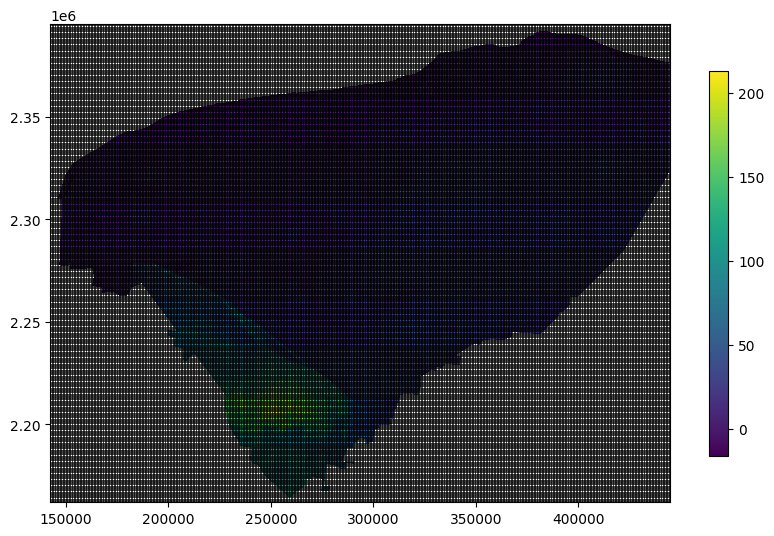

In [9]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1, aspect='equal')
ax = yucatan_raster.plot(ax=ax,vmin=vmin,vmax=vmax)
plt.colorbar(ax.images[0], shrink=0.5)
pmv = flopy.plot.PlotMapView(modelgrid=modelgrid)
pmv.plot_grid(ax=ax, lw=0.5, color='black')

In [10]:
# yucatanRaster_remuestreado = yucatan_raster.resample_to_grid(modelgrid, band=yucatan_raster.bands[0], method='nearest')
# np.save("yucatanRaster_remuestreado.npy", yucatanRaster_remuestreado)
# yucatanRaster_remuestreado = np.load("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelA\\structuredGrid\\yucatanRaster_remuestreado.npy")

In [11]:
# fig = plt.figure(figsize=(10,10))
# ax = fig.add_subplot(1,1,1, aspect='equal')
# pmv = flopy.plot.PlotMapView(modelgrid=modelgrid,ax=ax)
# pmv.plot_grid(ax=ax, lw=0.5, color='black')
# ax = pmv.plot_array(yucatanRaster_remuestreado, masked_values=yucatan_raster.nodatavals, vmin=vmin, vmax=vmax)
# plt.title(f"Resample time, nearest neighbor: {resample_time:.3f} sec")
# plt.colorbar(ax, shrink=0.5)

In [12]:
### CREATE THE FLOPY TEMPORAL DISCRETIZATION OBJECT
tdis = flopy.mf6.modflow.mftdis.ModflowTdis(
    sim, pname='tdis', time_units='SECONDS', nper=1, perioddata=[(1.0,1,1.0)]
)

In [13]:
## create the new modelgrid with the data of the yucatan's raster file
## we set the bottom layers using a two-layers model with 50 and 150 depth, respectively.
NODATA = 32767.0

idomain = np.where(yucatanRaster_remuestreado == NODATA,0,1)
idomain = np.stack([idomain, idomain], axis=0)
##
top = yucatanRaster_remuestreado.astype(float)
top[idomain[0] == 0] = np.nan ## for plottings and statistics
top_filled = np.where(np.isnan(top),0.0,top)

#raw mask of upland
upland_mask = (idomain[0]==1) & (top_filled >= 50.0)

botm1_thickness = 50.0
botm2_thickness = 200.0
botm_layer1 = top_filled - botm1_thickness
botm_layer1[upland_mask] = top[upland_mask] - 300.0 #making the upland zone with more thickness (300 m of thickness in this region)
##
botm_layer2 = botm_layer1 - botm2_thickness


btm = np.stack([botm_layer1, botm_layer2],axis=0)
# ##
btm[0] = np.where(idomain[0] == 1, btm[0],0.0)
btm[1] = np.where(idomain[1] == 1, btm[1],0.0)


modelgrid._top = top_filled
modelgrid._botm = btm
modelgrid.idomain = idomain

In [14]:
## CREATE THE FLOPY GROUNDWATER FLOW MODEL OBJECT
#modelname='yucatan_caseA'
#gwf = flopy.mf6.ModflowGwf(sim,modelname=modelname, newtonoptions='UNDER_RELAXATION')
gwf = flopy.mf6.ModflowGwf(sim, modelname=modelname)
gwf.modelgrid.set_coord_info(xoff=modelgrid._xoff, yoff=modelgrid._yoff, angrot=modelgrid._angrot, crs=modelgrid._crs)

In [15]:
### CREATE HE FLOPY INTERACTIVE MODEL SOLVER (IMS) PACKAGE OBJECT
ims = flopy.mf6.modflow.mfims.ModflowIms(sim,pname='ims',

                                         complexity='SIMPLE', # chooses a set of a reasonable defaults and lighter logging.

                                         outer_dvclose=1e-3, ## convergence criterion for the outer (non-linear) loop based on the max change in primary variables (heads). Stops outer iterations when thr max head change between consecutive outer iterations is < 1e-3 (meters)


                                         outer_maximum=300, #hard cap (limit) on the number of outer iterations per time step.... if you hit this number, the non-linear problem isn't settling (often a physics/etup issue, not just solver settings).


                                         inner_dvclose=1e-6,  ## convergence criterion for the inner (linear) solver, it stops the Krylov/CG iterations when the solution update is small enough.
                                                              ## typical range: 1e-4 to 1e-6 (dimesionless, solver-norm based), for stability with unconfined flow, 1e-5 or 1e-6 can reduce outer churn (fewer outer steps wasted on sloppy inner solves).

                                         inner_maximum=1200, # hard cap on inner iterations per outer step. If you frequently hit this cap, the matrix is hard to solve (constrant in K, dry/rewet, weird BCs)

                                         linear_acceleration="BICGSTAB", ## chooses the iterative linear solver. BICGSTAB: handles non-symmetric, ill-conditioned systems better tahn CG--good for unconfined and heterogeneus cases. CG:is fine (and often faster) for symmetric positive definite systems (e.g., confined, gentle K fileds). If CG stalls, go back to BICGSTAB

                                         relaxation_factor=0.92 ## damps updates in the outer loop (under-relaxation). 1.0 = no damping (fast but can oscillat/diverge). 0.7-0.98: is common. 0.97is a gentle brake--good for unconfined/coastal models.
                                                                 # if you see oscillation (outer iterations bouncing), drop to 0.9-0.95
                                                                 # if it's painfully slow but stable, try 0.98-0.99
                                        )

In [16]:

## CREATE THE FLOPY GROUNDWATER FLOW DISCRETIZATION OBJECT 
dis = flopy.mf6.modflow.mfgwfdis.ModflowGwfdis(
    gwf,
    pname='dis',
    nlay=modelgrid.nlay,
    nrow=modelgrid.nrow,
    ncol=modelgrid.ncol,
    delr=modelgrid.delr,
    delc=modelgrid.delc,
    top=modelgrid.top,
    botm=modelgrid.botm,
    idomain=modelgrid._idomain,
)


[<Axes: title={'center': ' top'}>,
 <Axes: title={'center': 'botm layer 1'}>,
 <Axes: title={'center': 'botm layer 2'}>,
 <Axes: title={'center': 'idomain layer 1'}>,
 <Axes: title={'center': 'idomain layer 2'}>]

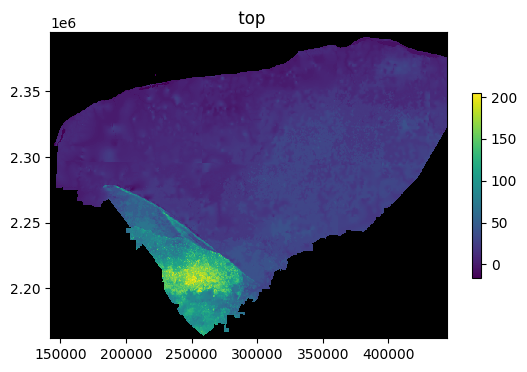

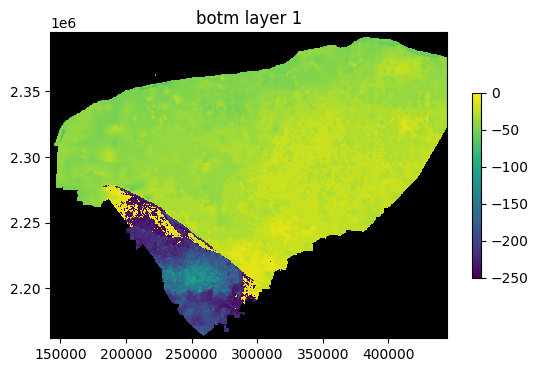

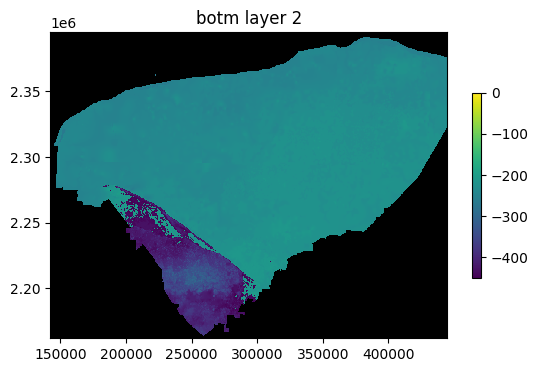

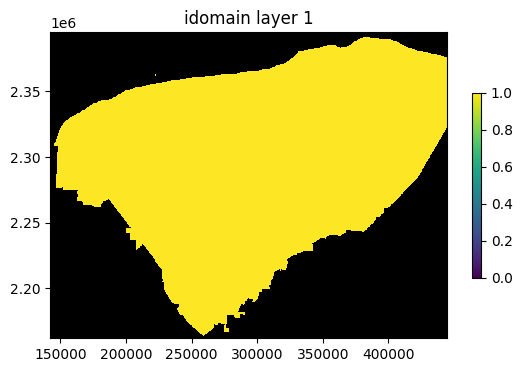

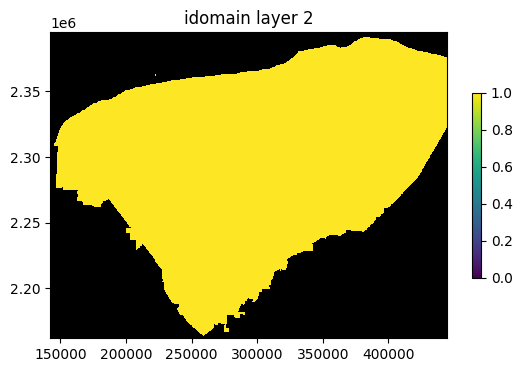

In [17]:
dis.plot()

In [18]:
### JOINING FEATURES AFF ALL CASE MODELS
xmin, xmax, ymin, ymax = modelgrid.extent
transform = from_origin(xmin,ymax,modelgrid.delr[0],modelgrid.delc[0]) #transform from gridcells to real-world coordinates

## Upland region mask
upland_mask = (idomain[0]==1) & (top_filled >= 50.0)

### Cenote ring mask
#buffer of cenotes ring
buf_dist = max(gwf.modelgrid.delr[0], gwf.modelgrid.delc[0]) # ~ WIdth of the cenotes ring (~ 5000 meters)

new_cenotesRing_mask = rasterize(
    [(geom.buffer(buf_dist),1) for geom in new_cenotesRing.geometry],
    out_shape=(modelgrid.nrow,modelgrid.ncol),
    transform = transform,
    fill=0
).astype(bool)

##
cenotesRing_cells = new_cenotesRing_mask & (idomain[0]==1) & (new_cenotesRing_mask != upland_mask)

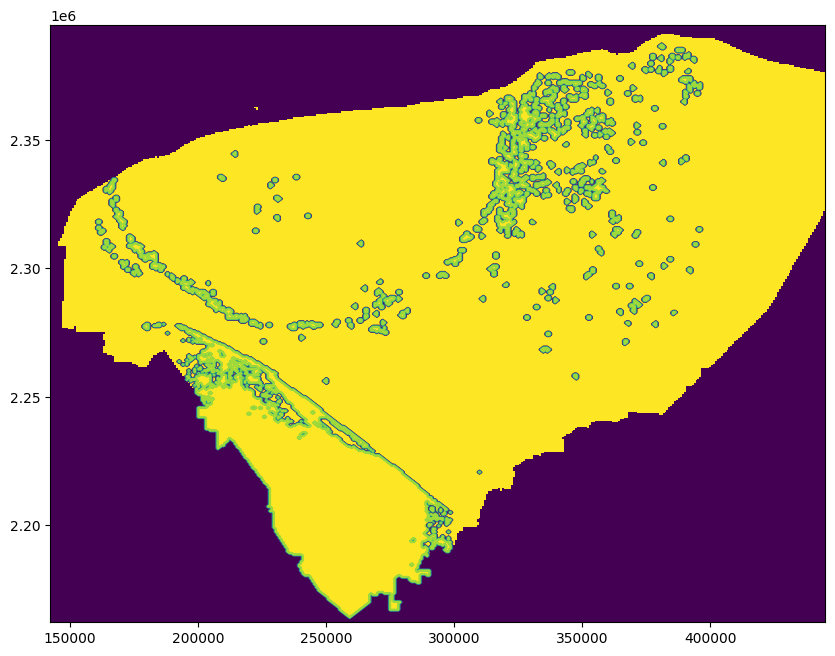

In [19]:
fig, ax = plt.subplots(figsize=(10,10))
pmv = flopy.plot.PlotMapView(modelgrid=modelgrid)
pa = pmv.plot_array(idomain[0])
pmv.contour_array(upland_mask)
pmv.contour_array(cenotesRing_cells)
#pmv.plot_grid(linewidth=0.5, color='gray')
#plt.colorbar(pc,shrink=0.5)

!!!! INTERPOLATION OF THE PIEZOMETRIC DATA

In [20]:
## Mapping of each well to it model cell (row,col) so we can:
# (a) drop point outside the model
# (b) test plausibility against top/bottom

#ij = [modelgrid.intersect(x,y) for x,y in zip(df.x,df.y)] ## mg.intersect: returns (row,col) of the cell that contains the X,Y point
#                                                           ## returns None if the points is outside the grid extent       

In [21]:
# ok = []
# idom0= gwf.dis.idomain.array[0]
# for k,rc in enumerate(ij):
#     if rc is None:
#         ok.append(False) #outside the modelgrid ----> DROP
#         continue
#     r,c = rc ## row, column
#     if idom0[r,c] != 1:
#         ok.append(False)  ## inactive cells ----> DROP
#         continue
#     h = float(df.median_head_masl.iloc[k])

#     # Plausability check: head must be above deepest bottom + small buffer,
#     # and not way above ground (top + 10 m wiggle room to tolerate outliers)
#     if np.isfinite(h) and (h>=btm[-1,r,c]+0.5) and (h<=top_filled[r,c]+10.0):
#         ok.append(True)
#     else:
#         ok.append(False)
# df = df.loc[ok].copy() ##keep only good points

In [22]:
### BUILDING OBSERVATION ARRAYS FOR INTERPOLATION

# observed wells coordinates in meters
xy_obs = np.vstack([df.x.values, df.y.values]).T #shape [n_points,2]

z_obs = df.median_head_masl.values.astype(float) #head at wells
w_obs = df.weight.values.astype(float)  #weigts 0-1 (more measurements -> higher weight)

w_obs = np.clip(w_obs,1e-6,None) #prevents divide-by-zero

In [23]:
## Building the query grid = model cell centers to interpolate onto
# modelgrid.xcellcenters, modelgrid.ycellcenters ----> 1D arrays of X and Y for each column/row

Xc, Yc = modelgrid.xcellcenters, modelgrid.ycellcenters
xy_q = np.vstack([Xc.ravel(),Yc.ravel()]).T #shape [nrow*ncol,2]


In [24]:

def idw_weighted_knn(xy_obs, z_obs, w_obs, xy_q,k, power, eps=1e-12, exact_tol=1e-9,normalize_weights=True, return_diag=False):

    # 1) filter invalid obs
    obs_ok = np.isfinite(z_obs) & np.isfinite(w_obs)
    xy_o = xy_obs[obs_ok]; z_o = z_obs[obs_ok]; w_o = w_obs[obs_ok]
    if xy_o.shape[0] == 0:
        raise ValueError("No valid observations after filtering.")

    # 2) clamp k
    k = int(min(max(1, k), xy_o.shape[0]))

    # 3) normalize obs weights (optional but helpful)
    w = np.clip(w_o, 1e-12, None)
    if normalize_weights:
        med = np.nanmedian(w)
        if np.isfinite(med) and med > 0:
            w = w / med

    # 4) KD-tree query
    tree = cKDTree(xy_o)
    dist, idx = tree.query(xy_q, k=k, p=2, workers=-1)
    if k == 1:
        dist = dist[:, None]
        idx  = idx[:,  None]

    # 5) exact matches
    exact = dist[:, 0] <= exact_tol

    # 6) weights (avoid inf, 0)
    d = np.maximum(dist, eps)
    wd = (w[idx] / d**power)
    wd_sum = wd.sum(axis=1)

    # 7) interpolate
    zi = np.full(xy_q.shape[0], np.nan, dtype=float)
    not_exact = ~exact
    if np.any(not_exact):
        num = np.sum(wd[not_exact] * z_o[idx[not_exact]], axis=1)
        den = np.maximum(wd_sum[not_exact], eps)
        zi[not_exact] = num / den

    # 8) copy exact obs values directly
    if np.any(exact):
        zi[exact] = z_o[idx[exact, 0]]

    if return_diag:
        return zi, {"exact": exact, "wd_sum": wd_sum, "dist_min": dist[:,0]}
    return zi


In [25]:
### RUN IDW INTERPOLATION
    #Result: head_idw is a 2D field of heads (m a.s.l.) at cell centers
head_idw = idw_weighted_knn(xy_obs,z_obs,w_obs,xy_q,12,2.0).reshape(Xc.shape)

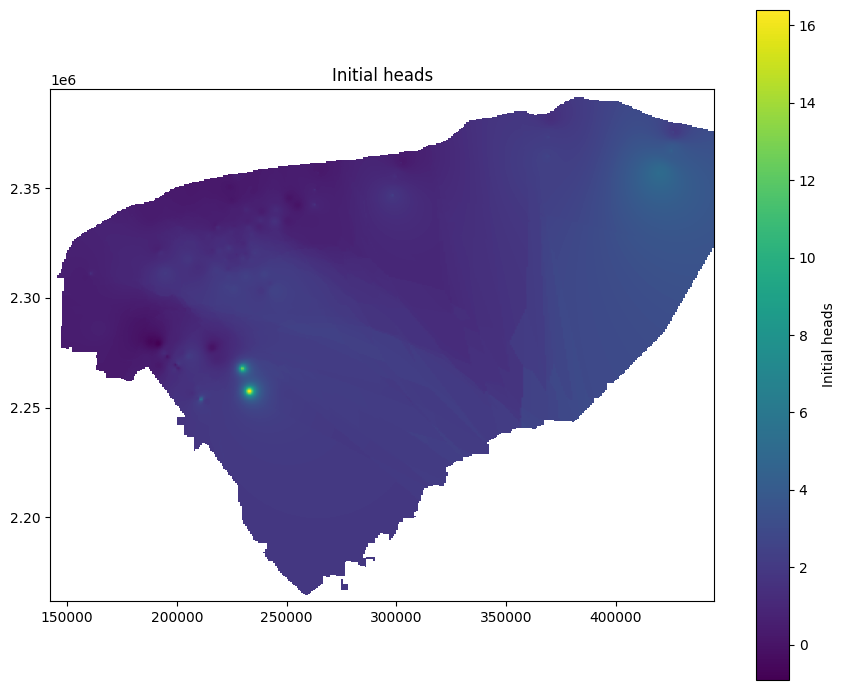

In [26]:
mask_L1 = (gwf.dis.idomain.array[0]==1)
R_plot = np.ma.masked_where(~mask_L1, head_idw)
plt.figure(figsize=(9,7))
im = plt.imshow(R_plot, extent=gwf.modelgrid.extent, origin="upper")
plt.colorbar(im, label="Initial heads")
plt.title("Initial heads")
plt.tight_layout(); plt.show()

In [27]:
### CLIP TO HYDROGEOLOGY AND BUILD LAYERED INITIAL CONDITIONS (strt)
    # Layer 1: head must be within [bottom_L1 + e, top - e]
    # Layer 2: head must be <= Layer 1 >= bottom_layer2+e
    # This prevents illegal starting head and helps convergence.

idom0= gwf.dis.idomain.array[0]

#Layer 1 (upper): clip between its bottom+0.5 and top-0.5 m
strt_l1 = np.clip(head_idw,np.min(btm[0]+0.5),np.max(top_filled.max()-0.5))
#strt_l1 = np.clip(head_idw,btm[0]+0.5,top_filled-0.5)

#layer 2 (lower): not above Layer 1, not below its own bottom
#strt_l2 = np.clip(np.minimum(strt_l1,head_idw-1.0), btm[1]+0.5, strt_l1)
strt_l2 = np.clip(head_idw, btm[1]+0.5, strt_l1)
## Outside idomain, put harmless values (they are ignored by solver)
strt_l1[idom0==0] = 0.0
strt_l2[idom0==0] = 0.0 

#stacking into a 3D array [nlay,nrow,ncol]
start = np.stack((strt_l1,strt_l2), axis=0)

## Create the initial conditions package
ic = flopy.mf6.modflow.mfgwfic.ModflowGwfic(gwf, pname='ic', strt=start)

[<Axes: title={'center': 'strt layer 1'}>,
 <Axes: title={'center': 'strt layer 2'}>]

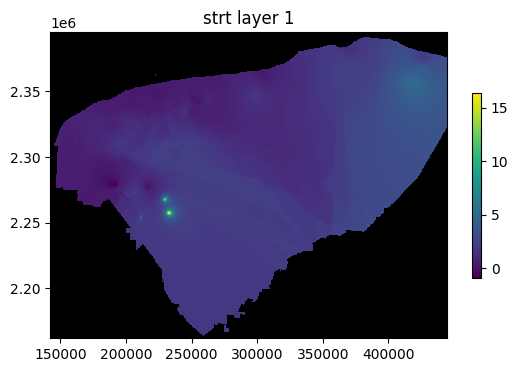

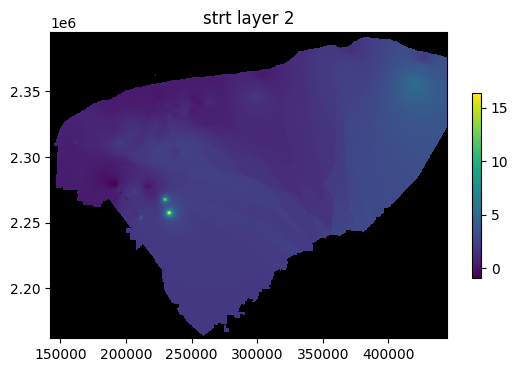

In [28]:
ic.plot()

In [29]:
## CREATE THE CONSTANT HEAD PACKAGE 
#use ~oe cell width for the buffer so the coastline touches cells
from rasterio.transform import from_origin

xmin, xmax, ymin, ymax = modelgrid.extent
buf_dist = 1500.0
transform = from_origin(xmin,ymax,modelgrid.delr[0],modelgrid.delc[0]) #transform from gridcells to real-world coordinates


coast_mask = rasterize(
    [(geom.buffer(buf_dist),1) for geom in coastline.geometry],
    out_shape=(modelgrid.nrow,modelgrid.ncol),
    transform = transform,
    fill=0
).astype(bool)

##
coastal_cells = np.where(coast_mask & (idom0==1))
r_inds, c_inds = coastal_cells

## Build CHD entries for Layer 1 at 0.0 m.a.s.l.
chd_coast_l1 = [((0,r,c),0.0) for r,c in zip(r_inds,c_inds)]
chd_coast_l2 = [((1,r,c),0.0) for r,c in zip(r_inds,c_inds)]

chd_coast = chd_coast_l1 + chd_coast_l2


[<Axes: title={'center': ' chd location stress period 1 layer 1'}>,
 <Axes: title={'center': ' chd location stress period 1 layer 2'}>]

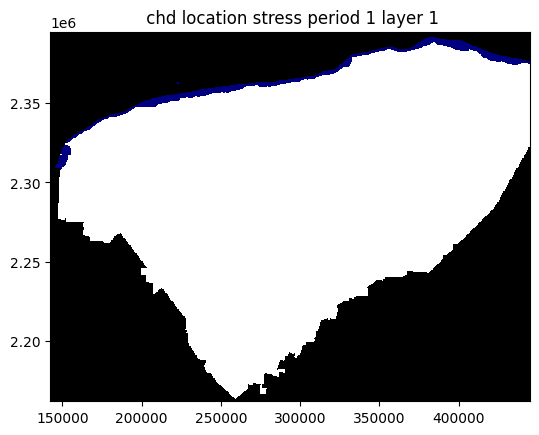

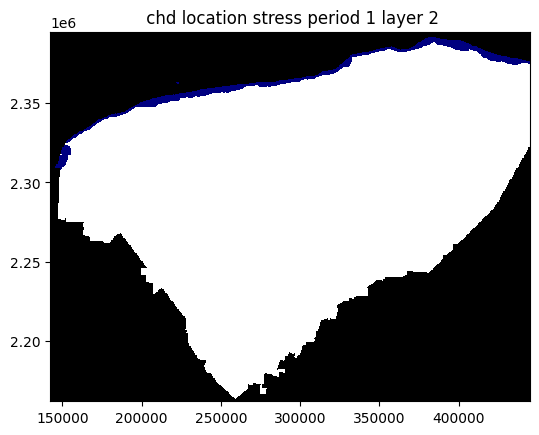

In [30]:
chd = flopy.mf6.modflow.mfgwfchd.ModflowGwfchd(
    gwf,
    pname ='chd',
    stress_period_data = {0:chd_coast},
    save_flows=True,
)

chd.plot()

In [31]:
# from scipy.ndimage import distance_transform_edt

# # coast_mask is boolean, True = inside buffer
# # distance outside the mask
# dist_outside = distance_transform_edt(coast_mask) #returs for each cell, the Euclidean distance to the nearest zero (False) cell in mask.

# # maximum distance in cells
# max_dist_cells = dist_outside[coast_mask].max()

# # convert cells → map units
# cell_size = max(gwf.modelgrid.delr[0], gwf.modelgrid.delc[0])
# width_measured = max_dist_cells * cell_size

# print("Measured buffer width ≈", width_measured, "map units")


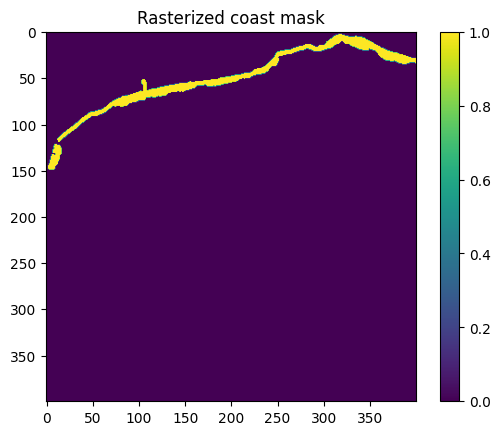

In [32]:
plt.imshow(coast_mask, origin="upper")
plt.title("Rasterized coast mask")
plt.colorbar()
plt.show()

In [33]:
# chd_mask = np.zeros((modelgrid.nrow, modelgrid.ncol), dtype=bool)
# for (lay, r, c), _h in chd_coast:
#     if lay == 0:
#         chd_mask[r, c] = True

# plt.figure(figsize=(10,8))
# plt.imshow(np.ma.masked_where(chd_mask==False,chd_mask), extent=modelgrid.extent, origin="upper", alpha=1.0)
# plt.imshow(np.ma.masked_where(idom0==0, idom0), alpha=0.1,extent=modelgrid.extent, origin="upper")
# plt.title("CHD cells (yellow) over active domain")
# plt.tight_layout(); plt.show()

In [34]:
# assigned = np.full((modelgrid.nrow, modelgrid.ncol), np.nan)
# for (lay, r, c), h in chd_coast:
#     if lay == 0:
#         assigned[r, c] = h

# plt.figure(figsize=(10,8))
# im = plt.imshow(assigned, extent=modelgrid.extent, origin="upper")
# plt.colorbar(im, label="CHD head (m a.s.l.)")
# plt.title("CHD head values applied (Layer 1)")
# plt.tight_layout(); plt.show()


In [35]:
## function to create K per layer as 2D array

def as_layer_array(val):
    if np.isscalar(val):
        return np.full((modelgrid.nrow,modelgrid.ncol), float(val))
    return np.asarray(val, float)

In [36]:
np.save("ring_cellids.npy", cenotesRing_cells)
np.save("upland_cellids.npy", upland_mask)

[<Axes: title={'center': 'icelltype layer 1'}>,
 <Axes: title={'center': 'icelltype layer 2'}>,
 <Axes: title={'center': 'k layer 1'}>,
 <Axes: title={'center': 'k layer 2'}>]

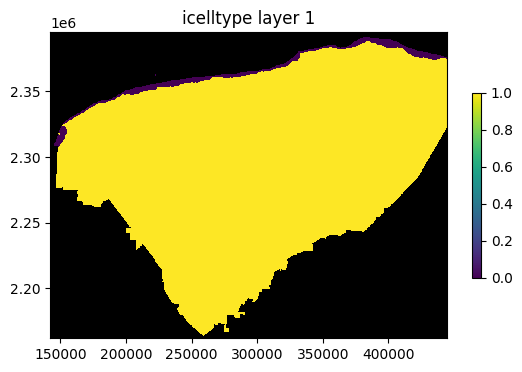

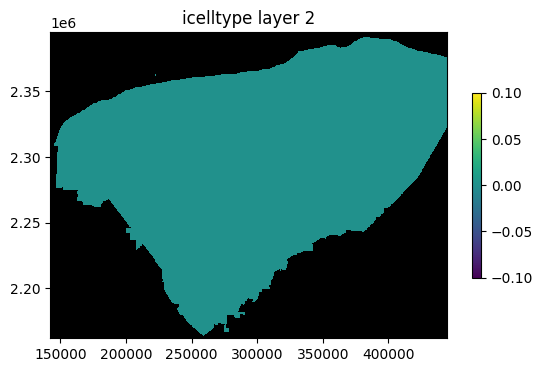

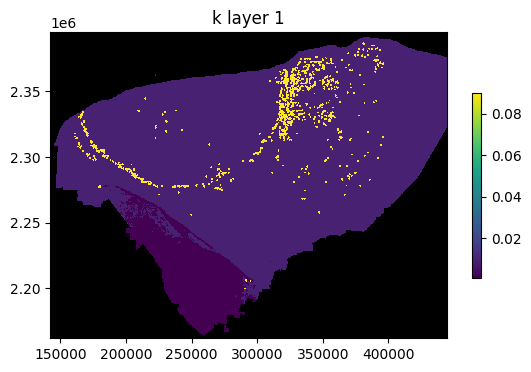

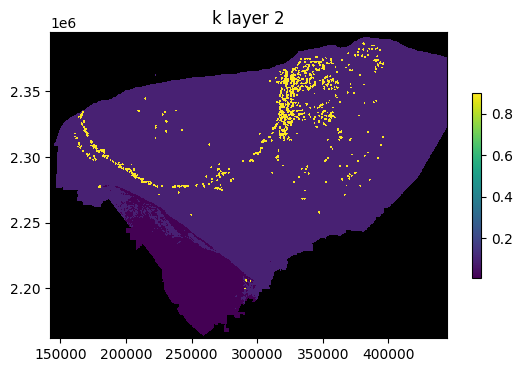

In [37]:
## Create the node property flow package
## icelltype = 1 for Layer 1 (unconfined: saturated thickness varies with computed head when head is below the cell top)
## icelltype = 0 for layer 2 (confined: means that saturated thickness is held constant)

# crating mask for layer 1: confined=band of coastline of the yucatan's state modelgrid, unconfined=rest of the yucatan's state modelgrid

layer1 = np.ones((modelgrid.nrow,modelgrid.ncol),dtype=int)
mask_confined = coast_mask & ((idom0==1).astype(bool))
layer1[mask_confined] = 0

icelltype = [layer1, np.zeros((modelgrid.nrow,modelgrid.ncol),dtype=int)]


k1 = as_layer_array(9e-3) #layer 1 --
k2 = as_layer_array(9e-2) #layer 2 -- 

k1 = np.where(cenotesRing_cells, 9e-2, k1) 
k2 = np.where(cenotesRing_cells, 9e-1, k2)

k1 = np.where(upland_mask, 1e-3, k1)
k2 = np.where(upland_mask, 1e-2, k2)

k = np.stack((k1,k2), axis=0)

## vertical conductivity

# k33_1 = as_layer_array(1e-2)
# k33_2 = as_layer_array(1e-1)

# k33_1 = np.where(upland_raw,1e-20,1e-2)
# k33_2 = np.where(upland_raw,1e-9, 1e-1)

#k33 = np.stack((k33_1,k33_2), axis=0)

## COMPUTE THE TRANSMISSIVIT FRACTIONS f1 AND f2 
b1 = np.maximum(top-botm[0], 0.1)
b2 = np.maximum(botm[0] - botm[1], 0.1)

T1 = k1 * b1 
T2 = k2 * b2 
T_total = T1 + T2
eps = 1e-12
f1 = T1 / (T_total + eps)
f2 = 1.0 - f1

### NODE PROPERTY FLOW PACKAGE CREATION 
npf = flopy.mf6.modflow.mfgwfnpf.ModflowGwfnpf(
    gwf, pname='npf', icelltype=icelltype, k=k, save_flows=True, save_specific_discharge=True,
)

npf.plot()

In [38]:
# fig = plt.figure(figsize=(10,10))
# ax = fig.add_subplot(1,1,1, aspect='equal')
# ax = population_raster.plot(ax=ax, cmap="turbo")
# plt.colorbar(ax.images[0], shrink=0.5)
# pmv = flopy.plot.PlotMapView(modelgrid=modelgrid)
# pmv.plot_grid(ax=ax, lw=0.1, color='black')

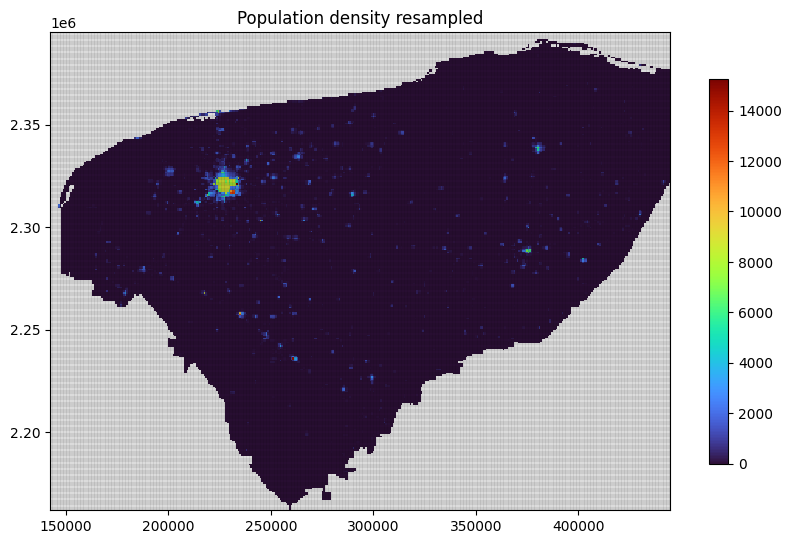

In [39]:
populationRaster_remuestreado = population_raster.resample_to_grid(modelgrid, band=population_raster.bands[0], method='nearest')
############
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1, aspect='equal')
pmv = flopy.plot.PlotMapView(modelgrid=modelgrid,ax=ax)
pmv.plot_grid(ax=ax, lw=0.1, color='black')
ax = pmv.plot_array(populationRaster_remuestreado, masked_values=population_raster.nodatavals, cmap="turbo")
plt.title("Population density resampled")
plt.colorbar(ax, shrink=0.5)

In [40]:
wel_list = []
idom = gwf.modelgrid.idomain
Hm3yr_to_m3s = 1e6 / (365.25*86400.0)

for idx, row in well_data.iterrows():
    Q_m3s = float(row["total"]) * Hm3yr_to_m3s
    if Q_m3s <= 0 or row.geometry is None or row.geometry.is_empty:
        continue

    muni_mask = rasterize(
        [(row.geometry, 1)],
        out_shape=(gwf.modelgrid.nrow, gwf.modelgrid.ncol),
        transform=transform,
        fill=0
    ).astype(bool)

    # Layer 2 footprint (active only) and avoid CHD if provided
    footprint = muni_mask & (idom[0].astype(bool) | idom[1].astype(bool))
    if coast_mask is not None:
        footprint &= ~coast_mask  # avoid shoreline CHD cells with the 2D coast mask

    r, c = np.where(footprint)
    if r.size == 0:
        continue

    # Population weights on footprint (spatial weights)
    w = populationRaster_remuestreado[r, c].astype(float)
    # Fallback to equal weights if population is 0/NaN
    if not np.isfinite(w).any() or np.all(w <= 0):
        w = np.ones_like(r, dtype=float)
    wsum = float(w.sum())
    if wsum <= 0:
        # extra guard
        w = np.ones_like(r, dtype=float)
        wsum = float(w.sum())

    rates = -Q_m3s * (w / wsum)

    # for rr,cc,q in zip(r,c,rates):
    #     f1_ = float(f1[rr,cc]) if idom[0,rr,cc] else 0.0
    #     f2_ = float(f2[rr,cc]) if idom[1,rr,cc] else 0.0
    #     denom = f1_ + f2_

    #     if denom <=  0.0: ## if both layers are inactive or zero T -- just skip
    #         continue
    #     if f1_ > 0:
    #         q1 = q * (f1_ / denom)
    #         wel_list.append(((0,int(rr),int(cc)), float(q1)))
    #     if f2_ > 0:
    #         q2 = q * (f2_ / denom)
    #         wel_list.append(((1,int(rr),int(cc)), float(q2)))

    for rr,cc, q in zip(r,c,rates):
        wel_list.append(((1,int(rr),int(cc)), float(q)))

##### CREATE OF THE WELL PACKAGE 
wel = flopy.mf6.modflow.mfgwfwel.ModflowGwfwel(
    gwf, pname="well_package", save_flows=True,
    stress_period_data={0: wel_list}   # <= dict, not bare list
)
print(f"WEL cells: {len(wel_list)} | total pumping m3/s = {sum(q for _, q in wel_list):.6f}")


WEL cells: 87488 | total pumping m3/s = -76.709481


[<Axes: title={'center': ' well_package location stress period 1 layer 1'}>,
 <Axes: title={'center': ' well_package location stress period 1 layer 2'}>]

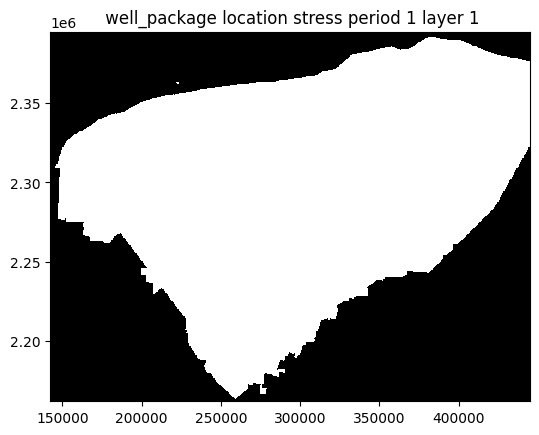

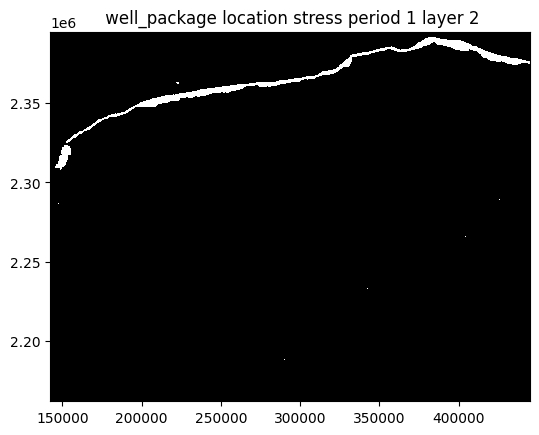

In [41]:
wel.plot()

In [42]:
# spd0 = wel.stress_period_data.get_data(0)
# print("SPD recs:", len(spd0))
# layers = {int(r["cellid"][0]) for r in spd0}
# print("Layers present:", sorted(layers))
# print("Total Q (m3/s):", sum(float(r["q"]) for r in spd0))

# # Build quick boolean maps per layer to visualize
# import numpy as np
# mask_L1 = np.zeros((gwf.modelgrid.nrow, gwf.modelgrid.ncol), bool)
# mask_L2 = np.zeros_like(mask_L1)
# for r in spd0:
#     k,i,j = r["cellid"]
#     (mask_L1 if k==0 else mask_L2)[i,j] = True

# # Plot with PlotMapView (clear and unambiguous)
# pmv = flopy.plot.PlotMapView(model=gwf)
# pmv.plot_array(mask_L1.astype(int), alpha=0.5)
# pmv.ax.set_title("WEL footprint L1 (should be empty)")
# pmv = flopy.plot.PlotMapView(model=gwf)
# pmv.plot_array(mask_L2.astype(int), alpha=0.5)
# pmv.ax.set_title("WEL footprint L2")


Text(0.5, 1.0, 'WEL cells – Layer 2')

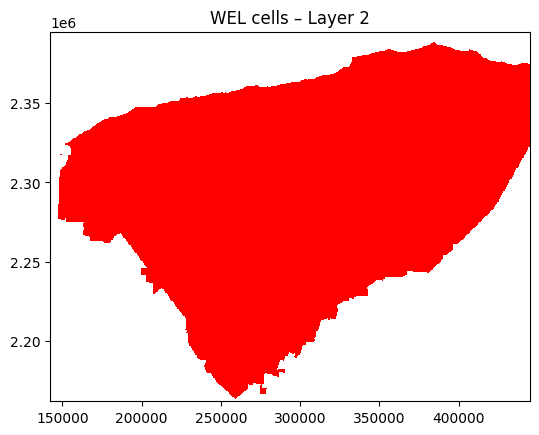

In [43]:

# Layer 0 (should be empty)
# pmv = flopy.plot.PlotMapView(model=gwf, layer=0)
# pmv.plot_bc("WEL", kper=0)
# pmv.ax.set_title("WEL cells – Layer 1 (should be none)")

# Layer 1 (your wells)
pmv = flopy.plot.PlotMapView(model=gwf, layer=1)
pmv.plot_bc("WEL", kper=0)
pmv.ax.set_title("WEL cells – Layer 2")


In [44]:
### loading the evaporation and precipitation data 
x = []
y = []
prec_values = []
prec_weight_values = []

folder = Path("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\precipitation_data")
for fp in folder.glob("*.csv"):
    #read the file
    df = pd.read_csv(fp)
    # ## extract coordinates values
    x_val = df["x"].dropna().values
    y_val = df["y"].dropna().values
    x.extend(x_val)
    y.extend(y_val)
    # extract precipitation data value
    prec_data = (df["mean_of_acum"].dropna().values) 
    prec_values.extend(prec_data) 
    # extract the weight data
        #For the case A use 25% of mean annual precipitation
    #weight_data = (df["weight"].dropna().values) * 0.25
    weight_data = (df["weight"].dropna().values) 
    prec_weight_values.extend(weight_data)
    
x_coords = np.array(x)
y_coords = np.array(y)
clima_coords = np.column_stack((x_coords, y_coords))
prec_values = np.array(prec_values)
prec_weight_values = np.array(prec_weight_values)

In [45]:
### interpolation of the precipitation data
prec_idw = idw_weighted_knn(clima_coords,prec_values,prec_weight_values,xy_q,12,2.0).reshape(Xc.shape)

In [46]:
## creating the recharge package
sec_per_year = 365*86400 #seconds in a year
c_inf = 0.25 #infiltration coefficient

## mask to active cells
idom = gwf.dis.idomain.array
idom0 = (idom[0]==1)
recharge = (prec_idw*1e-3*c_inf) / sec_per_year #recharge in meters per seconds
mR_upland = 1.0
mR_rest = 1.0

recharge[idom0 & upland_mask] *= mR_upland
recharge[idom0 & (~upland_mask)] *= mR_rest

records = [((0, r, c), float(recharge[r, c]))
           for r in range(recharge.shape[0])
           for c in range(recharge.shape[1])
           if idom0[r, c]]


if "rch" in gwf.get_package_list():
    gwf.remove_package("rch")
    
# CREATE THE RECHARGE (PRECIPITATION DATA) PACKAGE
rch = flopy.mf6.ModflowGwfrch(
    gwf,
    stress_period_data = {0:records}, #steady state; 1 period
    pname="rch",
    fixed_cell=True,
    print_flows=True,
    filename = "struc_caseD.rch",
    save_flows=True,
)

[<Axes: title={'center': ' rch location stress period 1 layer 1'}>,
 <Axes: title={'center': ' rch location stress period 1 layer 2'}>]

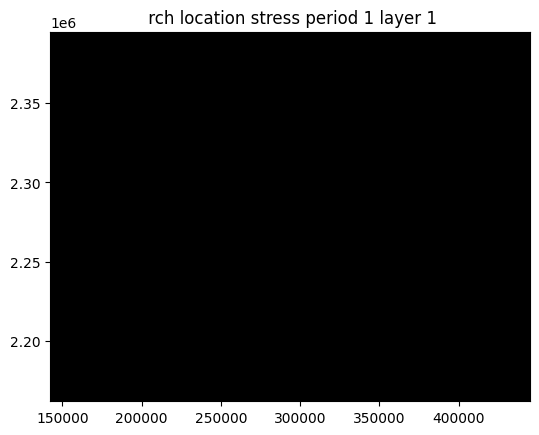

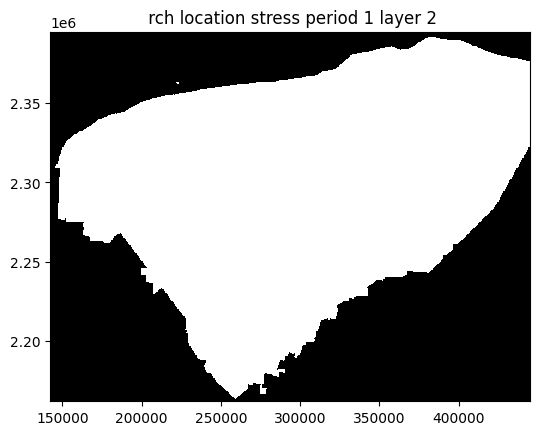

In [47]:
rch.plot()

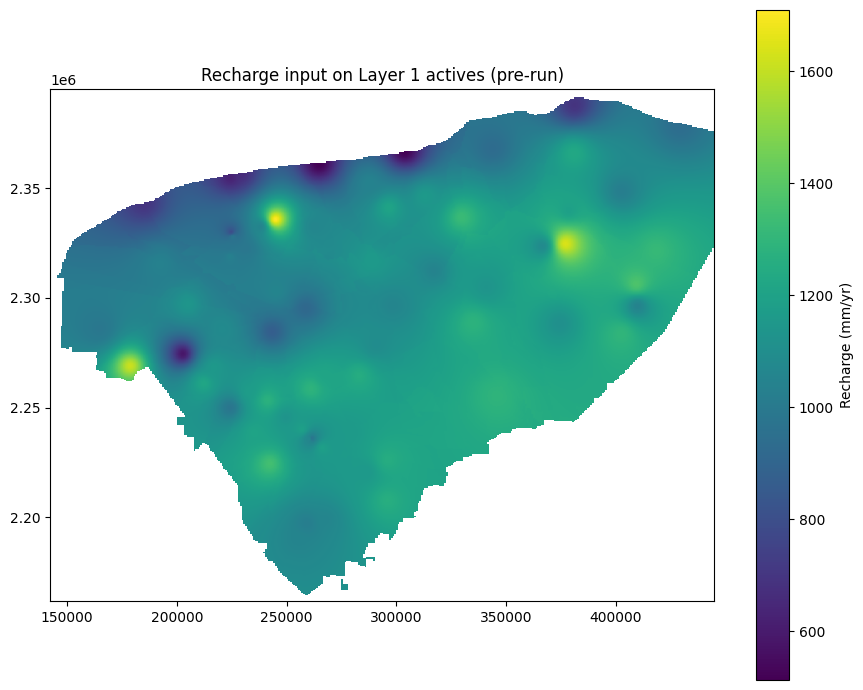

In [48]:
mask = (gwf.dis.idomain.array[0]==1)
data_prec = np.ma.masked_where(~mask, prec_idw)
plt.figure(figsize=(9,7))
im = plt.imshow(data_prec, extent=gwf.modelgrid.extent, origin="upper")
plt.colorbar(im, label="Recharge (mm/yr)")
plt.title("Recharge input on Layer 1 actives (pre-run)")
plt.tight_layout(); plt.show()

In [49]:
# mask_L1 = (gwf.dis.idomain.array[0]==1)
# R_plot = np.ma.masked_where(~mask_L1, R_mps)
# plt.figure(figsize=(9,7))
# im = plt.imshow(R_plot, extent=gwf.modelgrid.extent, origin="upper")
# plt.colorbar(im, label="Recharge (m/s)")
# plt.title("Recharge percentage input on Layer 1 ")
# plt.tight_layout(); plt.show()

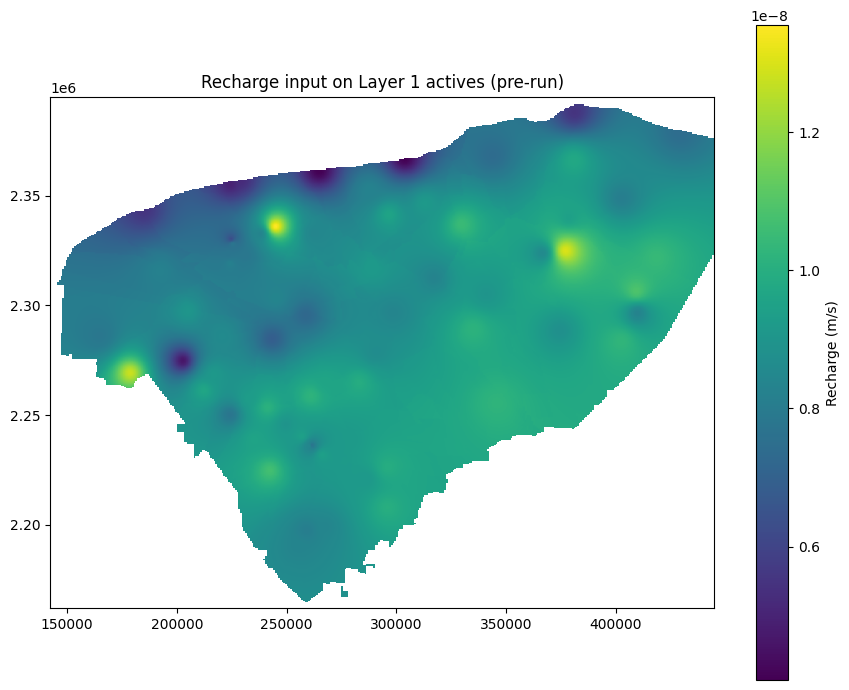

In [50]:
mask_L1 = (gwf.dis.idomain.array[0]==1)
R_plot = np.ma.masked_where(~mask_L1, recharge)
plt.figure(figsize=(9,7))
im = plt.imshow(R_plot, extent=gwf.modelgrid.extent, origin="upper")
plt.colorbar(im, label="Recharge (m/s)")
plt.title("Recharge input on Layer 1 actives (pre-run)")
plt.tight_layout(); plt.show()

In [51]:
# rch.plot()

In [52]:
# spd = rch.stress_period_data.get_data(0)  # list of ((k,r,c), rate)
# layers = {cellid[0] for cellid, _ in spd}
# print("Unique layers in RCH records:", layers)  # should be {0}
# print("Number of records:", len(spd))

In [53]:

# nlay, nrow, ncol = gwf.modelgrid.nlay, gwf.modelgrid.nrow, gwf.modelgrid.ncol
# hit = np.zeros((nlay, nrow, ncol), dtype=bool)

# for (k, r, c), rate in spd:
#     if rate != 0.0:
#         hit[k, r, c] = True

# # Plot layer 0 and layer 1 masks explicitly
# for k in range(min(2, nlay)):  # show first two layers
#     plt.figure(figsize=(7,6))
#     plt.imshow(hit[k], origin="upper", extent=gwf.modelgrid.extent)
#     plt.title(f"Cells with RCH records (k={k})")
#     plt.colorbar()
#     plt.tight_layout()
#     plt.show()


In [54]:
# ### DO THE SAME ABOVE CELL BUT FOR THE EVAPORATION DATA
# evap_values = []
# evap_weight_values = []

# folder = Path("C:\\Users\\sebas\\Downloads\\evaporation_data")
# for fp in folder.glob("*.csv"):
#     #read the file
#     df = pd.read_csv(fp)
#     # extract evaporation data values
#     evap_data = df["mean_of_acum"].dropna().values
#     evap_values.extend(evap_data)
#     # extract the weight data
#     weight_data = df["weight"].dropna().values
#     evap_weight_values.extend(weight_data)

# evap_values = np.array(evap_values)
# evap_weight_values = np.array(evap_weight_values)

### interpolation of the evaporation data
#evap_idw = idw_weighted_knn(clima_coords,evap_values,evap_weight_values,xy_q,k=12,power=2.0).reshape(Xc.shape)

In [55]:
# wrap longitudes to [-180, 180] if needed and sort
# if 'longitude' in data.coords:
#     lon = data['longitude']
#     if float(lon.max()) > 180.0: #ERA5 often 0..360
#         data = data.assign_coords(longitude=((lon+180)%360) - 180).sortby('longitude')

# if 'longitude' in pressure_data.coords:
#     lon = pressure_data['longitude']
#     if float(lon.max()) > 180.0: #ERA5 often 0..360
#         pressure_data = pressure_data.assign_coords(longitude=((lon+180)%360) - 180).sortby('longitude')

# print(data)

In [56]:
# data['ssr'].isel(valid_time=0).plot()
# plt.show()

In [57]:
# def prep_da_for_rio(da):
#     da = da.rio.write_crs(4326, inplace=False)
#     da = da.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
#     return da

In [58]:
## DATA NEEDED FOR THE ET0 COMPUTE

# d2m = prep_da_for_rio(data['d2m'])  
# t2m = prep_da_for_rio(data['t2m'])
# ssr = prep_da_for_rio(data['ssr'])
# Str = prep_da_for_rio(data['str'])
# u10 = prep_da_for_rio(data['u10'])
# v10 = prep_da_for_rio(data['v10'])

# pressure = prep_da_for_rio(pressure_data['sp'])

In [59]:
#attach CRS to ERA5 dataset and clip

# d2m = d2m.rio.write_crs(4326, inplace=False)
# t2m = t2m.rio.write_crs(4326, inplace=False)
# ssr = ssr.rio.write_crs(4326, inplace=False)
# Str = Str.rio.write_crs(4326, inplace=False)
# u10 = u10.rio.write_crs(4326, inplace=False)
# v10 = v10.rio.write_crs(4326, inplace=False)
# pressure = pressure.rio.write_crs(4326, inplace=False)

# # clip (keeps only inside the polygon); mask=True keeps outside as NaN

# d2m = d2m.rio.clip(yucatan.geometry, yucatan.crs, drop=True, invert=False)
# t2m = t2m.rio.clip(yucatan.geometry, yucatan.crs, drop=True, invert=False)
# ssr = ssr.rio.clip(yucatan.geometry, yucatan.crs, drop=True, invert=False)
# Str = Str.rio.clip(yucatan.geometry, yucatan.crs, drop=True, invert=False)
# u10 = u10.rio.clip(yucatan.geometry, yucatan.crs, drop=True, invert=False)
# v10 = v10.rio.clip(yucatan.geometry, yucatan.crs, drop=True, invert=False)
# pressure = pressure.rio.clip(yucatan.geometry, yucatan.crs, drop=True, invert=False)

In [60]:
## PLOT OF THE CLIMATOLOGY DATA

# data['ssr'].isel(valid_time=0).plot()
# # plt.show()
# v10.isel(valid_time=0).plot()
# plt.show()

In [61]:
# pressure.isel(valid_time=0).plot()
# plt.show()

In [62]:
## REGRID TO MY MODFLOW GRID
# from pyproj import Transformer
# from affine import Affine


# xmin, xmax, ymin, ymax = gwf.modelgrid.extent
# dx = float(gwf.modelgrid.delr[0])  # only if uniform
# dy = float(gwf.modelgrid.delc[0])  # only if uniform
# transform = Affine.translation(xmin, ymax) * Affine.scale(dx, -dy)
# nrow, ncol = gwf.modelgrid.nrow, gwf.modelgrid.ncol
# model_crs = "EPSG:32616"  # <-- my EPSG



# # # build a blank template in modelgrid
# template = xr.DataArray(np.zeros((nrow, ncol),dtype=np.float32),
#     dims=("y","x"), 
#     name="template").rio.write_transform(transform).rio.write_crs(model_crs)
#                                                                                     # .rio.write_transform(gwf.modelgrid.transform): Writes the affine transform (GDAL-style) that maps array indices (col/row) to real-world coordinates (x/y).
#                                                                                     #   This transform encodes:
#                                                                                     #       - pixel size (delr, delc)
#                                                                                     #       - origin (xoff, yoff)
#                                                                                     #       - rotation/skew if present

#                                                                                     # .rio.write_crs(gwf.modelgrid.crs): Writes the CRS (e.g., EPSG:32616). Now the DataArray is fully georeferenced and GIS tools know how to place it.

             
# ## HELPER TO REPROJECT AND MATCH ONE ERA5 VARIABLE (2D OR 3D WITH TIME)

# def to_model_grid_raster(da_ll, lon_name="longitude", lat_name="latitude"):
#     # 0..360 -> -180..180
#     # if float(da_ll[lon_name].max()) > 180:
#     #     da_ll = da_ll.assign_coords({lon_name: ((da_ll[lon_name]+180)%360)-180}).sortby(lon_name)
#     da_ll = da_ll.rio.write_crs("EPSG:4326").rio.set_spatial_dims(x_dim=lon_name, y_dim=lat_name)
#     da_prj = da_ll.rio.reproject(template.rio.crs)
#     return da_prj.rio.reproject_match(template)

# ## Now we regrid all needed variables
# d2m_m = to_model_grid_raster(d2m) #2m dewpoint temperature
# t2m_m = to_model_grid_raster(t2m) #2m temperature
# ssr_m = to_model_grid_raster(ssr) # surface net solar radiation
# str_m = to_model_grid_raster(Str) # surface net thermal radiation
# u10_m = to_model_grid_raster(u10) # 10m u-component of wind -- east-west (zonal) wind component at 10 m
# v10_m = to_model_grid_raster(v10) # 10m v-component of wind -- north-south (meridional) wind component at 10 m
# pressure_m = to_model_grid_raster(pressure)

In [63]:
## saving the regrided data as NetCDF4 file format

# d2m_m.to_netcdf("d2m_m.nc")
# t2m_m.to_netcdf("t2m_m.nc")
# ssr_m.to_netcdf("ssr_m.nc")
# str_m.to_netcdf("str_m.nc")
# u10_m.to_netcdf("u10_m.nc")
# v10_m.to_netcdf("v10_m.nc")
# pressure_m.to_netcdf("pressure_m.nc")

In [64]:
## LOADING OF THE NETCDF DATA

d2m_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\d2m_m.nc")
t2m_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\t2m_m.nc")
ssr_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\ssr_m.nc")
str_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\str_m.nc")
u10_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\u10_m.nc")
v10_m = xr.open_dataset("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\v10_m.nc")

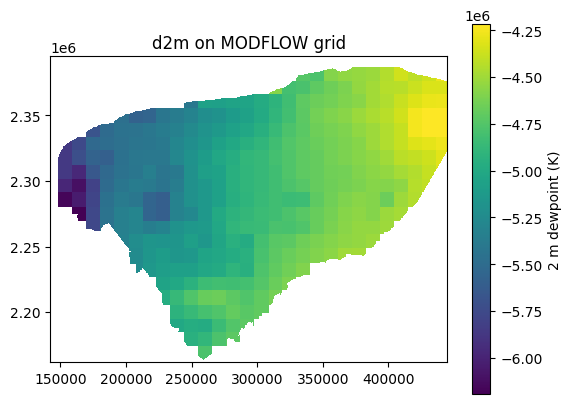

In [65]:
import flopy.plot as fplot

# we have to plot with map extent (not index), if not we would plotting in array index space, that always looks like a genric blob.
arr = str_m['str'].isel(valid_time=0).values
mask = (gwf.modelgrid.idomain[0] == 1)
arr_masked = np.where(mask, arr, np.nan)

pmv = fplot.PlotMapView(model=gwf, layer=0)
a = pmv.plot_array(arr_masked)
pmv.plot_grid(alpha=0)
plt.colorbar(a, label="2 m dewpoint (K)")
plt.title("d2m on MODFLOW grid")
plt.show()

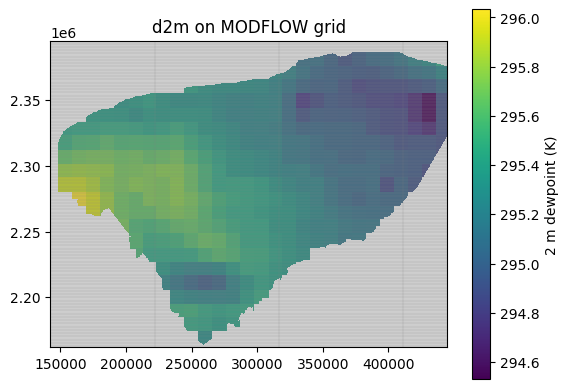

In [66]:
arr = t2m_m['t2m'].isel(valid_time=0).values
mask = (gwf.modelgrid.idomain[0] == 1)
arr_masked = np.where(mask, arr, np.nan)

pmv = fplot.PlotMapView(model=gwf, layer=0)
a = pmv.plot_array(arr_masked)
pmv.plot_grid(alpha=0.1)
plt.colorbar(a, label="2 m dewpoint (K)")
plt.title("d2m on MODFLOW grid")
plt.show()

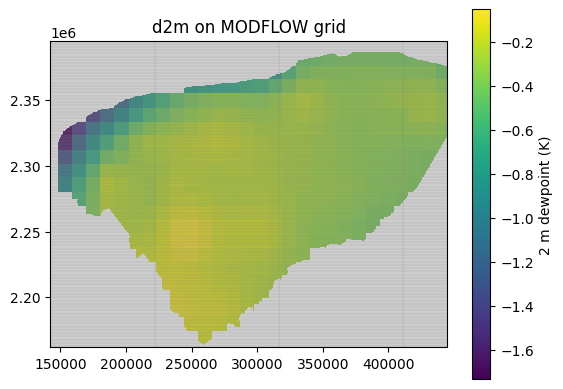

In [67]:
arr = v10_m['v10'].isel(valid_time=0).values
mask = (gwf.modelgrid.idomain[0] == 1)
arr_masked = np.where(mask, arr, np.nan)

pmv = fplot.PlotMapView(model=gwf, layer=0)
a = pmv.plot_array(arr_masked)
pmv.plot_grid(alpha=0.1)
plt.colorbar(a, label="2 m dewpoint (K)")
plt.title("d2m on MODFLOW grid")
plt.show()

In [68]:
# print("Rn stats:", float(Rn.min()), float(Rn.max()))
# print("Tmean_C stats:", float(Tmean_C.min()), float(Tmean_C.max()))
# print("Tdew_C stats:", float(Tdew_C.min()), float(Tdew_C.max()))
# print("u2 stats:", float(u2.min()), float(u2.max()))

In [69]:
# print("es min/max:", float(es.min()), float(es.max()))
# print("ea min/max:", float(ea.min()), float(ea.max()))


In [70]:
## CONVERT UNITS AND COMPUTE ET0 (MONTHLY)
# radiation [J/m2] per month ----> MJ/m2/day; temps K---->°C; wind to 2 m, etc..

time = ssr_m['valid_time'].to_index() #taks the "time" coordinate of my NetCDF variable and converts it into Pandas index (likely DatetimeIndex) so i can use pandas functionality on it.

days_in_month = xr.DataArray(
    time.to_series().dt.days_in_month.values,
    coords={'valid_time' : ssr_m['valid_time']}
)  # ----> This code builds an xarray DataArray where each time step stores the number of days in its month. It lines up perfectly with my NetCDF time dimension, so i can use it later for calculations 

# Convert units of solar and thermal radiation to MJ/m2/day(MJ/m2 per day),  (before J/m2 per month)
Rns = (ssr_m['ssr']/ days_in_month) / 1e6 #now daily average shortwave radiation 
Rnl = (str_m['str'] / days_in_month) / 1e6 #now daily average longwave radiation
Rn = Rns + Rnl

## Convertion from K grades to °C for 2m temperature and dewpoint temperature
Tmean_C = t2m_m['t2m'] - 273.15 
Tdew_C = d2m_m['d2m'] - 273.15

# Wind: 10 m ----> 2 m 
u10 = np.hypot(u10_m['u10'], v10_m['v10'])  # -----> here im computing the magitude of the wind vector (speed in m/s) at 10 meters above the ground
u2 = u10 * (4.87 / np.log(67.8*10.0 - 5.42)) # This uses the FAO-56 ogarithmic wind profile adjusment, # ≈ 0.748*u10

## Saturation and actual vapour pressure (kPa)
def esat_kpa(Tc): return 0.6108*np.exp((17.27*Tc)/(Tc+237.3)) ## -----> This function is a saturation vapor pressure equation (the maximum water vapor pressure that air can hold at a given temperature), straight out of the FAO-56 evapotranspiration method. 
                                                                #       Saturtion vapor pressure is a key ingredient for calculating actual vapor pressure, vapor pressure deficit (VPD), and a reference evapotranspiration (ET0). Represents the water demand of the air at a given temperature.
                                                              ##        Output: Units = kilopascals (kPa)


## The difference between (es-ea) is the vapor pressure deficit (VPD), i.e., how "dry" the air is
#  Units : kPa
es = esat_kpa(Tmean_C) ## ---> saturation vapor pressure at mean air temperature
ea = esat_kpa(Tdew_C) ## ---> actual vapor pressure at dew-point temperature -- dew point is when air is saturated, so it´s actual vapor pressure 

#Slope of vapour pressure curve (kPa/°C): formula from FA0-56: slope of saturation vapor pressure curve at kPa/°C (it measures how sensitive vapor pressure is to temperature)
delta = (4098.0 * es) / ((Tmean_C + 237.3)**2)   

# Convert Pa to kPa
#P_kPa = pressure_m / 1000.0
P_kPa = xr.zeros_like(Tmean_C) + 101.3
gamma = 0.000665 * P_kPa # psychrometric constant gamma (kPa/°C)

## FAO-56 PM (mm/day); soil heat flux G ~ 0 monthly
T_k = Tmean_C + 273.0 # converts air temperature in °C to Kelvin; needed because the ET0 formula has a term 900/T where T must be in Kelvin.
ET0 = (0.408*delta*Rn + gamma*(900.0/T_k)*u2*(es-ea)) / (delta + gamma*(1.0 + 0.34*u2)) # this is the FAO-56 Penman-Monteith reference evapotranspiration equation (mm/day)
ET0 = ET0.clip(min=0.0) ## no negative values 

In [71]:
fgw = 0.30 #groundwater fraction
exdp_val = 2.0
mFGW_upland = 1.0
mFGW_rest = 1.0

idom2d = (gwf.modelgrid.idomain[0] == 1)
rate_mps = (fgw*ET0*1e-3) / 86400.0 ##mm/d ---> m/s
#rate_mps_mm_yr = fgw*ET0
##map to active cells
surf = top_filled.astype(float)
exdp = np.full_like(surf, exdp_val, dtype=float)

rate_ss = rate_mps.mean(dim='valid_time').values ## rate of maximum EVT flux rate 
rate_ss[upland_mask] *= mFGW_upland
rate_ss[~upland_mask] *= mFGW_rest

#rate_ss_mmYr = rate_mps_mm_yr.mean(dim='valid_time').values
# build records only where active and ET>0
spd0 = []
maskk = idom2d & (rate_ss > 0)
evt_mask = maskk & ~coast_mask
r_idx, c_idx = np.where(evt_mask)
for r,c in zip(r_idx, c_idx):
    spd0.append([(0, int(r), int(c)), float(surf[r,c]), float(rate_ss[r,c]), float(exdp[r,c])])

evt = flopy.mf6.modflow.mfgwfevt.ModflowGwfevt(
    gwf, pname='evt',
    maxbound = len(spd0), #integer values specifying the maximum number of evapotranspiration cells that will be specified for use during any stress period
    stress_period_data = {0: spd0}, #dictionary keyed by stress period
    save_flows=True,
    nseg=1 # single linear segment
)

print(f"EVT cells (SS): {len(spd0)}")

# FOR TRANSIENT MONTHLY MODE

# # Build TDIS first with one period per month (SECONDS)
# months = rate_mps['time'].to_index()
# perlens = (months.to_series().dt.days_in_month.values * 86400.0).astype(float)
# perioddata = [(float(p), 1, 1.0) for p in perlens]
# tdis = flopy.mf6.modflow.mftdis.ModflowTdis(
#     sim, pname='tdis', time_units='SECONDS',
#     nper=len(perioddata), perioddata=perioddata
# )

# # Build EVT SPD per month
# evt_spd = {}
# for sp, _ in enumerate(months):
#     rate2d = rate_mps.isel(time=sp).values  # m/s
#     spd = []
#     r_idx, c_idx = np.where(idom2d & (rate2d > 0))
#     for r, c in zip(r_idx, c_idx):
#         spd.append([(0, int(r), int(c)), float(surf[r, c]), float(rate2d[r, c]), float(exdp[r, c])])
#     evt_spd[sp] = spd

# evt = flopy.mf6.modflow.mfgwfevt.ModflowGwfevt(
#     gwf, pname='evt_monthly',
#     maxbound=max(len(v) for v in evt_spd.values()),
#     stress_period_data=evt_spd,
#     save_flows=True,
#     nseg=1
# )
# print("EVT monthly built. Example SP0 entries:", len(evt_spd[0]))

EVT cells (SS): 86632


In [72]:
# mask_evt = (gwf.dis.idomain.array[0]==1)
# data_evt = np.ma.masked_where(~mask_evt, rate_ss_mmYr)
# plt.figure(figsize=(9,7))
# im = plt.imshow(data_evt, extent=gwf.modelgrid.extent, origin="upper")
# plt.colorbar(im, label="Evapotranspiration (mm/yr)")
# plt.title("EVT on layer 1")
# plt.tight_layout(); plt.show()

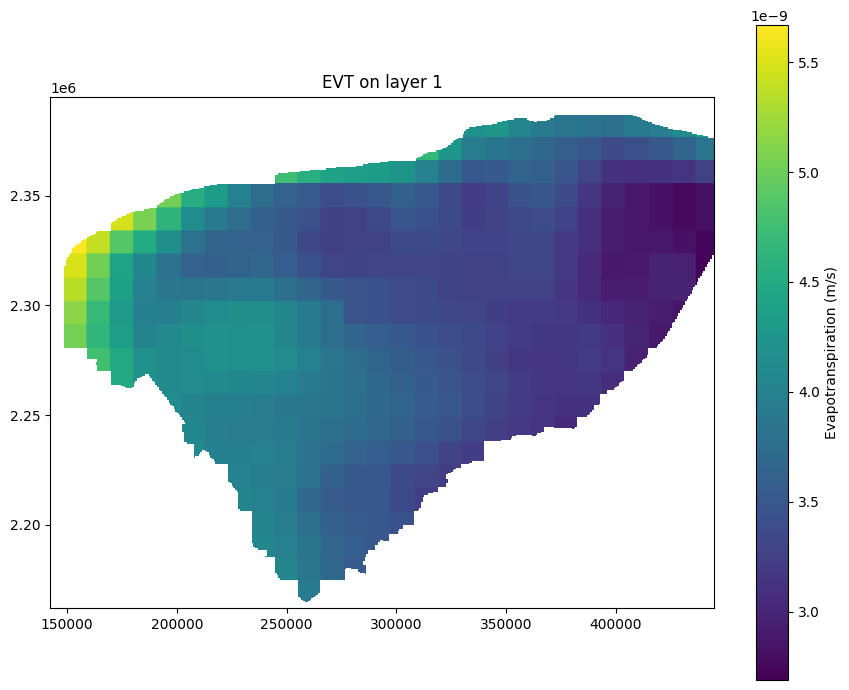

In [73]:
mask_evt = (gwf.dis.idomain.array[0]==1)
data_evt = np.ma.masked_where(~mask_evt, rate_ss)
plt.figure(figsize=(9,7))
im = plt.imshow(data_evt, extent=gwf.modelgrid.extent, origin="upper")
plt.colorbar(im, label="Evapotranspiration (m/s)")
plt.title("EVT on layer 1")
plt.tight_layout(); plt.show()

In [74]:
# idom = gwf.modelgrid.idomain
# idom2d = (idom[0] == 1) if idom.ndim == 3 else (idom == 1)
# print("Active cells(top): ", idom2d.sum())

In [75]:
# # What dims does your ET series have?
# print("rate_mps dims:", getattr(rate_mps, "dims", "not xarray"))
# print("rate_mps shape:", np.shape(rate_mps))

In [76]:
# # Try to pick the right time dim
# time_dim = None
# for cand in ("time","valid_time","month","date"):
#     if hasattr(rate_mps, "dims") and cand in rate_mps.dims:
#         time_dim = cand
#         break
# print("Chosen time dim:", time_dim)

In [77]:

# # Compute steady-state mean using the detected time dim
# if time_dim is not None:
#     rate_ss = rate_mps.mean(dim=time_dim).values
# else:
#     # if rate_mps is already 2D numpy
#     rate_ss = np.array(rate_mps)

# print("rate_ss stats (m/s): min=", np.nanmin(rate_ss), 
#       " med=", np.nanmedian(rate_ss), " max=", np.nanmax(rate_ss))

# # Count cells that would be written
# n_evt = int(np.count_nonzero(idom2d & np.isfinite(rate_ss) & (rate_ss > 0)))
# print("Cells with ET>0 & active:", n_evt)

In [78]:
## OUTPUT CONTROL PACKAGE
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord="struc_caseD.hds",
    budget_filerecord = "struc_caseD.cbc",
    saverecord=[("HEAD","LAST"), ("BUDGET","LAST")],
    printrecord=[("BUDGET","LAST")]

)

In [79]:
## write simulation
success = sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model struc_caseD...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package chd...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 4424 based on size of stress_period_data
    writing package npf...
    writing package well_package...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 87488 based on size of stress_period_data
    writing package rch...
INFORMATION: maxbound in ('gwf6', 'rch', 'dimensions') changed to 89705 based on size of stress_period_data
    writing package evt...
    writing package oc...


In [80]:
ok, buff = sim.run_simulation()

FloPy is using the following executable to run the model: ..\..\..\..\..\anaconda3\Scripts\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.0 12/20/2024

   MODFLOW 6 compiled Dec 31 2024 17:10:16 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the

In [81]:
# spd0 = chd.stress_period_data.get_data(0)  # SP0
# print("CHD entries SP0:", len(spd0))
# uniq_layers = sorted(set([int(r["cellid"][0]) for r in spd0]))
# print("CHD layers present:", uniq_layers)

In [82]:
# # Any of these CHD cells inactive or zero-thickness?
# bad = 0
# for r in spd0:
#     k, i, j = r["cellid"]
#     if idomain[k, i, j] != 1:
#         bad += 1
# print("CHD cells on inactive cells:", bad)

In [83]:
# from flopy.utils import Mf6ListBudget
# lst = Mf6ListBudget("yucatan_caand he seA.lst")
# df, dfc = lst.get_dataframes()
# print(df.tail(12))  # last rows

In [84]:
# Total recharge volume (m3/d) implied by your RCH array
# delr = gwf.modelgrid.delr
# delc = gwf.modelgrid.delc
# if delr.size == 1:  # uniform cellsize
#     area = delr[0] * delc[0]
#     act = (idomain[0] == 1)  # top active cells receive RCH
#     tot_rch_m3d = float((recharge[act]).sum() * area)
# else:
#     # variable spacing
#     A = np.outer(delc, delr)  # [nrow,ncol]
#     act = (idomain[0] == 1)
#     tot_rch_m3d = float((recharge[act] * A[act]).sum())
# print("Total recharge (m3/d):", f"{tot_rch_m3d:,.1f}")

# CHD outflow from list budget:
# In df rows find 'CHD' and 'RCH' entries; compare magnitudes.


In [85]:
from flopy.utils import Mf6ListBudget

lst = Mf6ListBudget(f"{modelname}.lst")
df, _ = lst.get_dataframes()

print(df.columns) 
print(df.head(10))

Index(['WEL_IN', 'RCH_IN', 'EVT_IN', 'CHD_IN', 'TOTAL_IN', 'WEL_OUT',
       'RCH_OUT', 'EVT_OUT', 'CHD_OUT', 'TOTAL_OUT', 'IN-OUT',
       'PERCENT_DISCREPANCY'],
      dtype='object')
                            WEL_IN      RCH_IN  EVT_IN  CHD_IN    TOTAL_IN  \
1970-01-01 00:00:01.000002     0.0  343.810608     0.0     0.0  343.810608   

                              WEL_OUT  RCH_OUT  EVT_OUT     CHD_OUT  \
1970-01-01 00:00:01.000002  76.709503      0.0   4.4107  262.694702   

                             TOTAL_OUT    IN-OUT  PERCENT_DISCREPANCY  
1970-01-01 00:00:01.000002  343.814911 -0.004237                 -0.0  


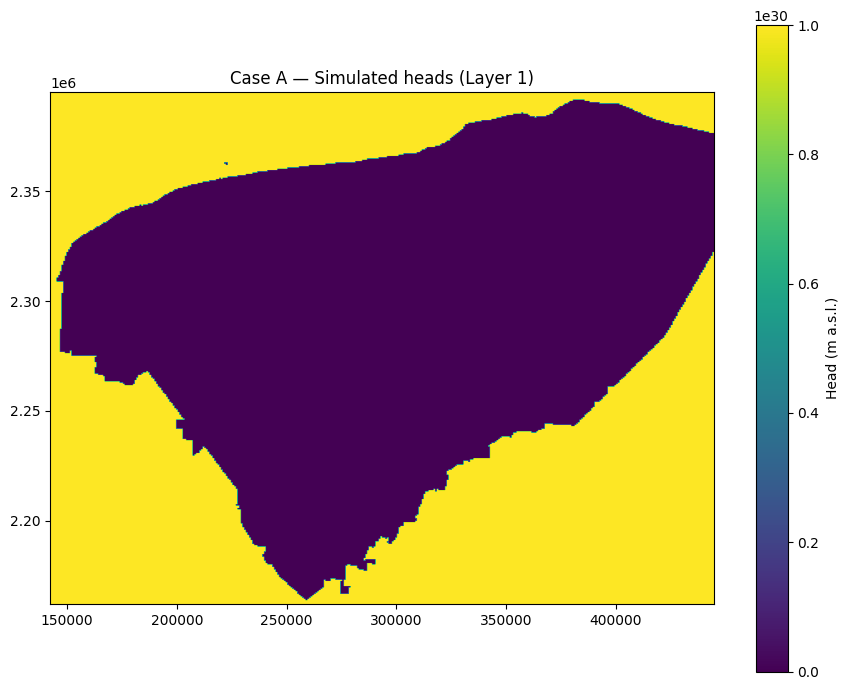

Budget record names: [b'    FLOW-JA-FACE', b'      DATA-SPDIS', b'             WEL', b'             RCH', b'             EVT', b'             CHD']


In [86]:
# Heads (steady-state → one output)
hobj = gwf.output.head()
h = hobj.get_data(kstpkper=(0,0))           # shape (nlay, nrow, ncol)
h1 = np.where(gwf.dis.idomain.array[0]==1, h[0], np.nan)

plt.figure(figsize=(9,7))
im = plt.imshow(h[0], extent=gwf.modelgrid.extent, origin="upper")
plt.colorbar(im,label="Head (m a.s.l.)")
plt.title("Case A — Simulated heads (Layer 1)")
plt.tight_layout(); plt.show()

# Budget summary
bud = gwf.output.budget()
# MF6 prints a summary in console via OC; here’s a quick check of net imbalance:
from flopy.utils.utils_def import totim_to_datetime
# total IN and OUT from budget text (optional: parse bud file)
recnames = bud.get_unique_record_names()
print("Budget record names:", recnames)


Text(0.5, 1.0, 'Cargas hidráulicas simuladas - Capa 1 \n Caso D - Malla estructurada')

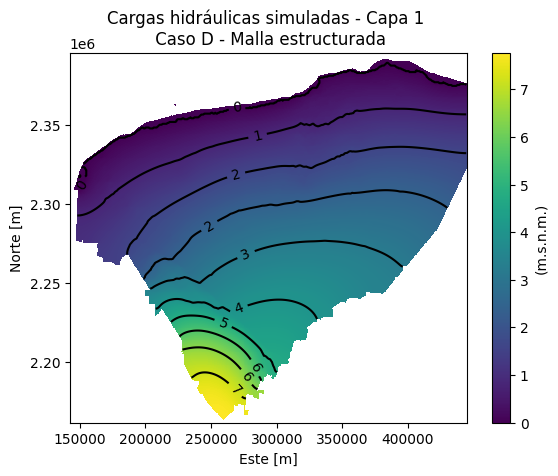

In [87]:

fig, ax = plt.subplots()
modelMap = flopy.plot.PlotMapView(model=gwf,ax=ax,layer=0)
hd = modelMap.plot_array(h[0],ax=ax,alpha=1.0,cmap='viridis')
#linecollection = modelmap.plot_grid(lw=0.4)
contour = modelMap.contour_array(h[0],ax=ax,levels=10,colors='black')
plt.colorbar(hd, label="(m.s.n.m.)")
labels = plt.clabel(contour,fmt="%1.0f")

cbc = flopy.utils.CellBudgetFile("struc_caseD.cbc", precision="double")
spdis = cbc.get_data(text="DATA-SPDIS")[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)

# fname = os.path.join("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_caseA.cbc")
# cbb = flopy.utils.CellBudgetFile(fname,precision='double') #This statement read and extract data from the MODFLOW /cbc file- the cell-by-cell budget file
#                                                             #This file stores flow information for each cell in the model such as:
#                                                            # Flow between cells (e.g. horizontal and vertical flows)
#                                                            # Flor from packages (e.g. recharge, wells, drain, etc..)
# spdis = cbb.get_data(text='DATA-SPDIS')[0] #Specific Discharge Data: water's flow by area (vectores de flujo), me proporciona los vectores de flujo 
#                                            # [0] means that we will get the data of 'DATA-SPDIS' of the first time period 
# ## Components of the flux vectors
# qx = -spdis['qx']
# qy = -spdis['qy']
# qz = -spdis['qz']
# #flow directions
# xcentergrid = gwf.modelgrid.xcellcenters
# ycentergrid = gwf.modelgrid.ycellcenters
#plt.quiver(xcentergrid,ycentergrid,qx[0],qy[0],scale=1e-1000,color='red',pivot='middle')
plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Cargas hidráulicas simuladas - Capa 1 \n Caso D - Malla estructurada')


Text(0.5, 1.0, 'Cargas hidráulicas simuladas - Capa 2 \n Caso D - Malla estructurada')

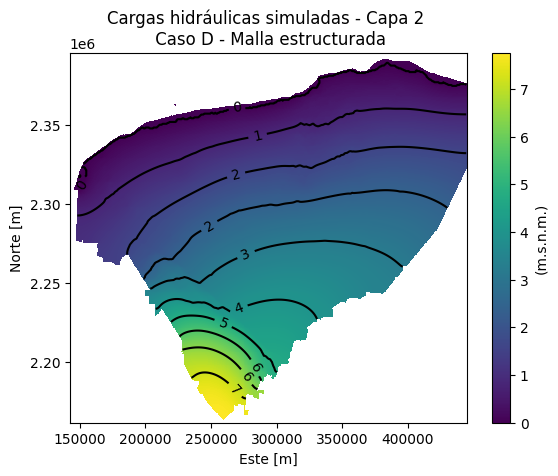

In [88]:
fig, ax = plt.subplots()
modelMap = flopy.plot.PlotMapView(model=gwf,ax=ax,layer=0)
hd = modelMap.plot_array(h[1],ax=ax,alpha=1.0, cmap='viridis')
#linecollection = modelmap.plot_grid(lw=0.4)
contour = modelMap.contour_array(h[1],ax=ax,levels=10, colors='black',
                               )
plt.colorbar(hd, label="(m.s.n.m.)")
labels = plt.clabel(contour,fmt="%1.0f")

cbc = flopy.utils.CellBudgetFile("struc_caseD.cbc", precision="double")
spdis = cbc.get_data(text="DATA-SPDIS")[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)
plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Cargas hidráulicas simuladas - Capa 2 \n Caso D - Malla estructurada')

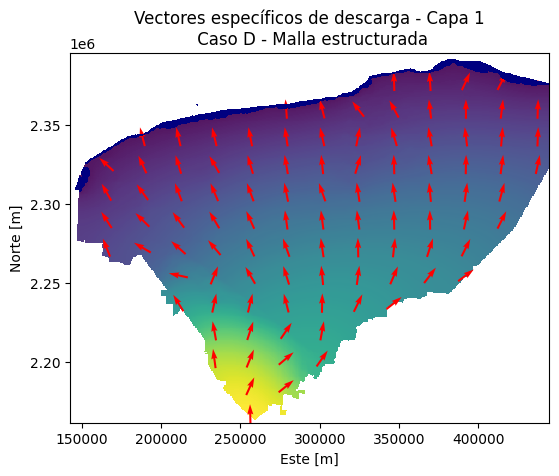

In [89]:
# Mask inactive cells in layer 1
mask0 = (idomain[0] != 1)
qx0 = qx[0].copy(); qy0 = qy[0].copy()
qx0[mask0] = np.nan; qy0[mask0] = np.nan

# Optional: background heads for layer 1
#from flopy.utils import HeadFile
hds = flopy.utils.HeadFile("struc_caseD.hds", precision="double")
h = hds.get_data(kstpkper=(0,0))  # steady-state
h1 = h[0]; h1[mask0] = np.nan

pmv = flopy.plot.PlotMapView(model=gwf, layer=0)
pmv.plot_array(h1, alpha=0.7)
# stride the arrows so you can actually see patterns
pmv.plot_vector(qx[0], qy[0], istep=30, jstep=30,normalize=True,  color='red')
pmv.plot_bc("CHD")  # nice sanity overlay
plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Vectores específicos de descarga - Capa 1\n Caso D - Malla estructurada')
plt.show()


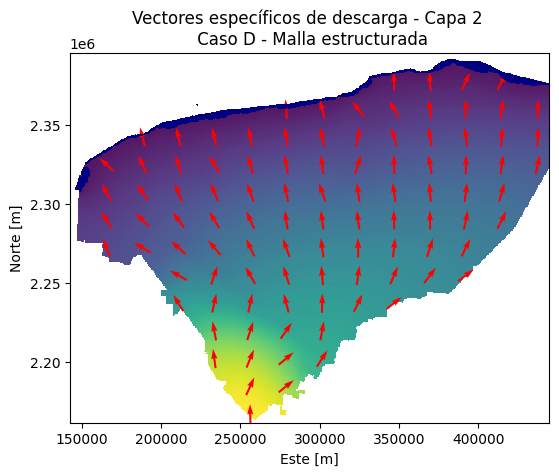

In [90]:
# Mask inactive cells in layer 1
mask0 = (idomain[0] != 1)


pmv = flopy.plot.PlotMapView(model=gwf, layer=1)
pmv.plot_array(h[1], alpha=0.7)
# stride the arrows so you can actually see patterns
pmv.plot_vector(qx[1], qy[1], istep=30, jstep=30, normalize=True, color='red')
pmv.plot_bc("CHD")  # nice sanity overlay
plt.title("Specific discharge vectors (Layer 2)")
plt.xlabel('Este [m]')
plt.ylabel('Norte [m]')
plt.title('Vectores específicos de descarga - Capa 2 \n Caso D - Malla estructurada')
plt.show()


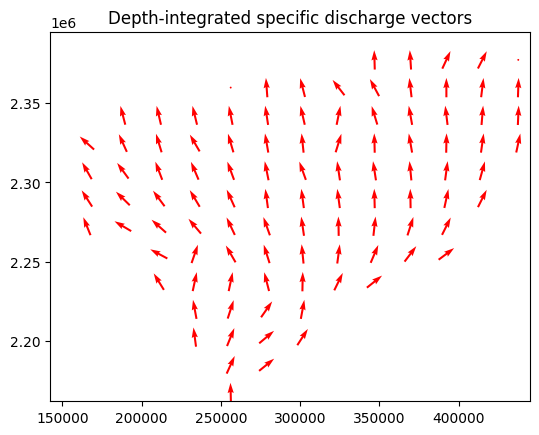

In [91]:
# Sum over layers (units remain [L/T]): this is the vertically-integrated specific discharge
qx2d = np.nansum(qx, axis=0)
qy2d = np.nansum(qy, axis=0)

# Mask with top layer idomain
qx2d[mask0] = np.nan
qy2d[mask0] = np.nan

pmv = flopy.plot.PlotMapView(model=gwf)
pmv.plot_vector(qx2d, qy2d, istep=30, jstep=30, normalize=True, color='red')  # magnitudes visible
plt.title("Depth-integrated specific discharge vectors")
plt.show()


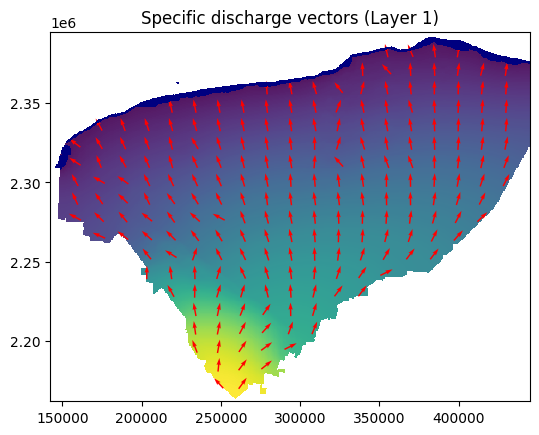

In [92]:
pmv = flopy.plot.PlotMapView(model=gwf, layer=0)
pmv.plot_array(h1, alpha=0.7)
# stride the arrows so you can actually see patterns
pmv.plot_vector(qx2d, qy2d, istep=20, jstep=20,normalize=True,  color='red')
pmv.plot_bc("CHD")  # nice sanity overlay
plt.title("Specific discharge vectors (Layer 1)")
plt.show()


In [93]:
df = pd.read_csv("C:\\Users\\sebas\\Documents\\AYUDANTE SNI\\TESIS\\yucatan_modelD\\structuredGrid\\obs_heads.csv") # piezometric heads values
print(df)

                   obs_id            x            y  head_obs  weight
0    w_1A_PLANTEL_SN_JUAN  265134.2561  2357511.741     0.250       1
1        w_1B_SAN_EDUARDO  263783.7281  2349649.333     0.515       1
2     w_1C_QUINTA_ROSARIO  263623.8627  2343030.648     0.740       1
3       w_2A_DZILAM_BRAVO  302925.3018  2361985.296     0.270       1
4        w_2B_DZILAM_GLEZ  300492.6609  2355912.776     0.990       1
..                    ...          ...          ...       ...     ...
130           RM12CHEUMAN  218798.1289  2331984.650     1.330       1
131         RM13TIXCUYTUN  232927.4588  2331630.856     1.420       1
132          RM14MEGALITA  238348.8424  2335224.646     1.320       1
133    RM15SIERRA_PAPACAL  216696.0836  2338201.703     0.675       1
134        RM18_SAC_NICTE  231623.2825  2340055.166     0.950       1

[135 rows x 5 columns]


In [94]:
rows = []
cols = []

for _,r in df.iterrows():
    x = float(r["x"]); y = float(r["y"])
    ij = [gwf.modelgrid.intersect(x,y)]

    if ij is None:
        raise RuntimeError(f"Point not in grid: x={x} y={y}")

    rows.append(ij[0][0])
    cols.append(ij[0][1])


In [95]:
h[0].shape

(400, 400)

In [96]:
## Mapping of each well to it model cell (row,col) so we can:


ij = [gwf.modelgrid.intersect(x,y) for x,y in zip(df.x,df.y)] ## mg.intersect: returns (row,col) of the cell that contains the X,Y point
                                                          ## returns None if the points is outside the grid extent   

ij = np.array(ij) 
rows = ij[:,0]                                                       
cols = ij[:,1]

wells = np.zeros_like(yucatanRaster_remuestreado, dtype=int)

# Keep only indices that fall inside the raster bounds (safety)
nrow, ncol = wells.shape
ok = (rows >= 0) & (rows < nrow) & (cols >= 0) & (cols < ncol)

# Mark wells
wells[rows[ok], cols[ok]] = 1